# Fake News Detection — Exploratory Data Analysis (EDA)

This notebook explores the dataset, analyzes text distributions, and validates preprocessing steps.

In [6]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [8]:
# Load data
df = pd.read_csv('../data/raw/news.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (47246, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [9]:
# Basic info
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Label Distribution ---')
print(df['label'].value_counts())


--- Data Types ---
title      object
text       object
subject    object
date       object
label       int64
dtype: object

--- Missing Values ---
title      0
text       0
subject    0
date       0
label      0
dtype: int64

--- Label Distribution ---
label
1    25829
0    21417
Name: count, dtype: int64


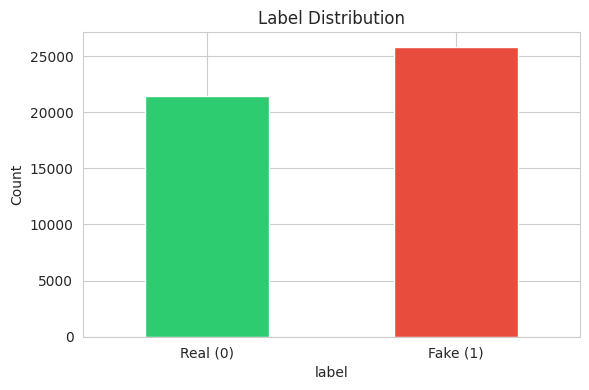

In [14]:
# Label distribution plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['label'].value_counts().sort_index().plot(
    kind='bar',
    ax=ax,
    color=['#2ecc71', '#e74c3c']
)
ax.set_xticklabels(['Real (0)', 'Fake (1)'], rotation=0)
ax.set_title('Label Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

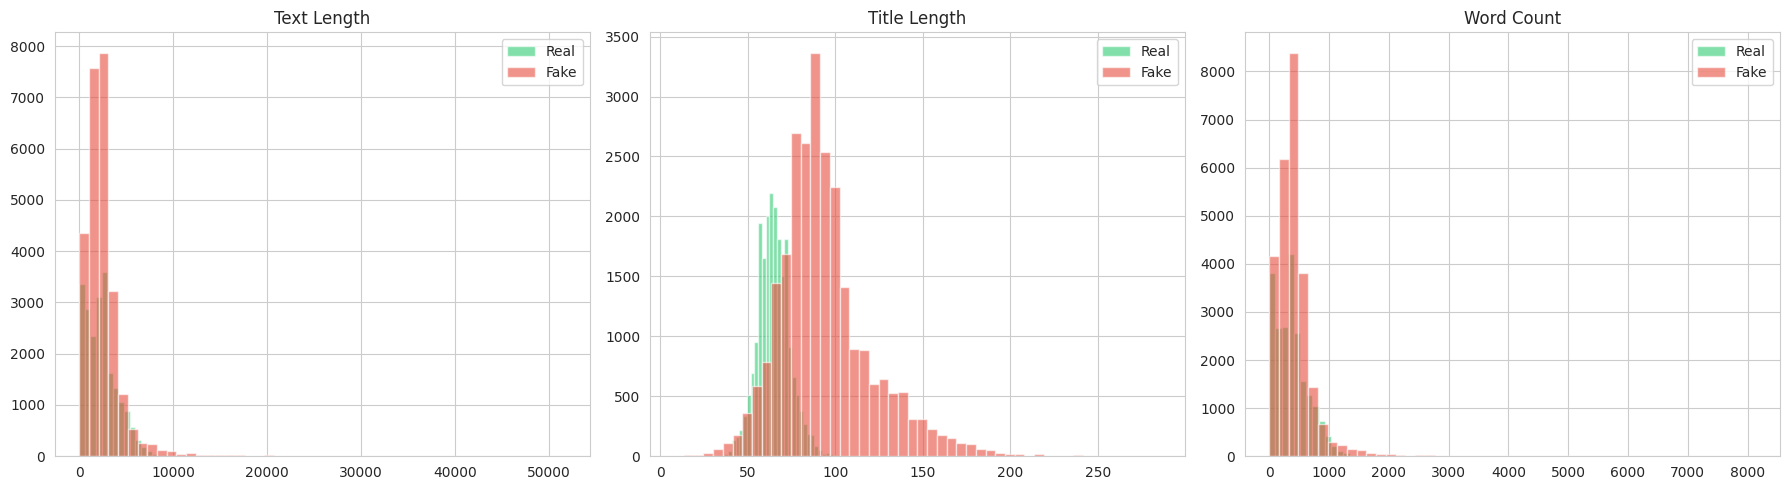

In [11]:
# Text length analysis
df['text_length'] = df['text'].fillna('').str.len()
df['title_length'] = df['title'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate([('text_length', 'Text Length'), ('title_length', 'Title Length'), ('word_count', 'Word Count')]):
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = df[df['label'] == label][col]
        axes[i].hist(subset, bins=50, alpha=0.6, color=color, label=f"{'Real' if label==0 else 'Fake'}")
    axes[i].set_title(title)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [12]:
# Baseline statistics for drift detection
print('--- Baseline Statistics ---')
for col in ['text_length', 'title_length', 'word_count']:
    print(f'\n{col}:')
    print(f'  Mean:   {df[col].mean():.2f}')
    print(f'  Std:    {df[col].std():.2f}')
    print(f'  Median: {df[col].median():.2f}')
    print(f'  Min:    {df[col].min()}')
    print(f'  Max:    {df[col].max()}')

--- Baseline Statistics ---

text_length:
  Mean:   2472.95
  Std:    2179.07
  Median: 2185.00
  Min:    1
  Max:    51794

title_length:
  Mean:   80.79
  Std:    25.65
  Median: 74.00
  Min:    8
  Max:    286

word_count:
  Mean:   406.21
  Std:    352.68
  Median: 362.00
  Min:    0
  Max:    8135


In [13]:
# Test preprocessing pipeline
import sys
sys.path.insert(0, '..')
from src.data.preprocess import clean_text, preprocess_dataframe

# Test cleaning
sample = 'BREAKING: Visit http://fake.com for <b>shocking</b> news! #viral @user'
print(f'Original: {sample}')
print(f'Cleaned:  {clean_text(sample)}')

Original: BREAKING: Visit http://fake.com for <b>shocking</b> news! #viral @user
Cleaned:  breaking visit for shocking news viral user


# Summary

## Key Findings from EDA

### 1. Dataset Balance
The dataset is reasonably balanced:
- Real (0): ~21.4k samples  
- Fake (1): ~25.8k samples  

There is a slight skew toward fake news, but it is not significant enough to require resampling. The dataset is suitable for training without major class imbalance concerns.


### 2. Text vs Title Characteristics
- **Text Length**
  - Mean ≈ 2473 characters  
  - High standard deviation (≈ 2179)  
  - Maximum ≈ 51,794  
  - Indicates a highly variable distribution with extreme outliers

- **Title Length**
  - Mean ≈ 80 characters  
  - Lower variability (Std ≈ 25)  
  - More consistent across samples  

**Insight:** Titles are more stable and may provide stronger consistent signals, while full text introduces variability and noise.


### 3. Differences Between Real and Fake News
- Fake news tends to show slightly different distributions in:
  - Text length  
  - Title length  
  - Word count  

- Real news appears more centrally distributed.

**Insight:** Length-based features (e.g., title length, word count) can serve as useful predictors.


### 4. Word Count Distribution
- Mean ≈ 406 words  
- Maximum ≈ 8135 words  
- Highly skewed distribution with long-tail behavior  

**Implication:**  
Feature scaling (e.g., normalization or log transformation) may be required to handle extreme values.


### 5. Missing Values
- No missing values across all columns:
  - title, text, subject, date, label  

**Insight:**  
No imputation or data cleaning required for missing data.


### 6. Baseline Statistics for Drift Detection
Baseline statistics were computed for:
- text_length  
- title_length  
- word_count  

These include mean, standard deviation, median, min, and max.

**Importance:**  
These values can be used later for:
- Data drift detection  
- Monitoring production data consistency  

### 7. Preprocessing Pipeline Validation
The preprocessing pipeline successfully:
- Removes URLs  
- Removes HTML tags  
- Cleans special characters  
- Converts text to lowercase  

**Result:**  
Consistent and clean input suitable for model training.


## Final Insight
The dataset is clean and well-structured, with:
- High variability in text features  
- Stable and informative title features  
- Useful statistical baselines for monitoring  

A strong modeling approach would combine:
- Semantic text features (e.g., embeddings)  
- Engineered features (e.g., text length, word count)


## One-Line Summary
Clean, balanced dataset with high text variability; titles and length-based features provide strong predictive signals, and baseline statistics enable effective drift monitoring.